# Correlations between soundscape indices

Load csv with acoustics indices calculated for comparison with species metrics (richness, abondance) or with acoustics metrics (richness, total amount, simpson...)

Combine both dataframes, with species richnesse as well as with soundtypes richness.
The indices were computed on XX different biomes :
- Shrubland - Subtropical-tropical moist
- Forest - Subtropical-tropical moist lowland
- Forest - Temperate
- Forest - Boreal
- Desert - Hot
- Wetland
- Freshwater

and 8 different datasets :
- dB@risoux
- dB@jahra
- dB@rambouillet
- dB@petchora
- viloam
- santarèm
- wasmannia

In [79]:
"============== LOAD LIBRARIES ============"

library(data.table)
library(corrplot)


[1] "============== LOAD LIBRARIES ============"

In [80]:
"============== OPTIONS ============"
CORRELATION_TYPE = 'spearman'

[1] "============== OPTIONS ============"

In [81]:
"============== IMPORT CSV ============"
#import data
data = fread("../data/13dB_15min_no_optim/data_species.csv")

# Extract the acoustic index only
data_index = data[,c(2:61)]

[1] "============== IMPORT CSV ============"

[1] "================================="
[1] "The most correlated index are "
            indice1         indice2 correlation_r        pvalue
1               ZCR            NDSI     0.8370190  0.000000e+00
2               ZCR             rBA     0.8370190 8.741200e-101
3              VARt            LEQt     0.9999653 1.258333e-254
4              VARt            BGNt     0.9126287 3.616009e-212
5              VARt               M     0.9126287  0.000000e+00
6              VARt           MEANf     0.8746753  0.000000e+00
7              VARt            VARf     0.9720182  0.000000e+00
8              VARt            LEQf     0.9762461 2.100378e-238
9              VARt            BGNf     0.8870309 2.229902e-233
10             VARt    AnthroEnergy     0.8080389  0.000000e+00
11             VARt             ROU     0.9704971  0.000000e+00
12            KURTt            SNRt     0.8954205  9.184295e-83
13            KURTt              Ht    -0.9186072 3.229627e-283
14            KURTt        

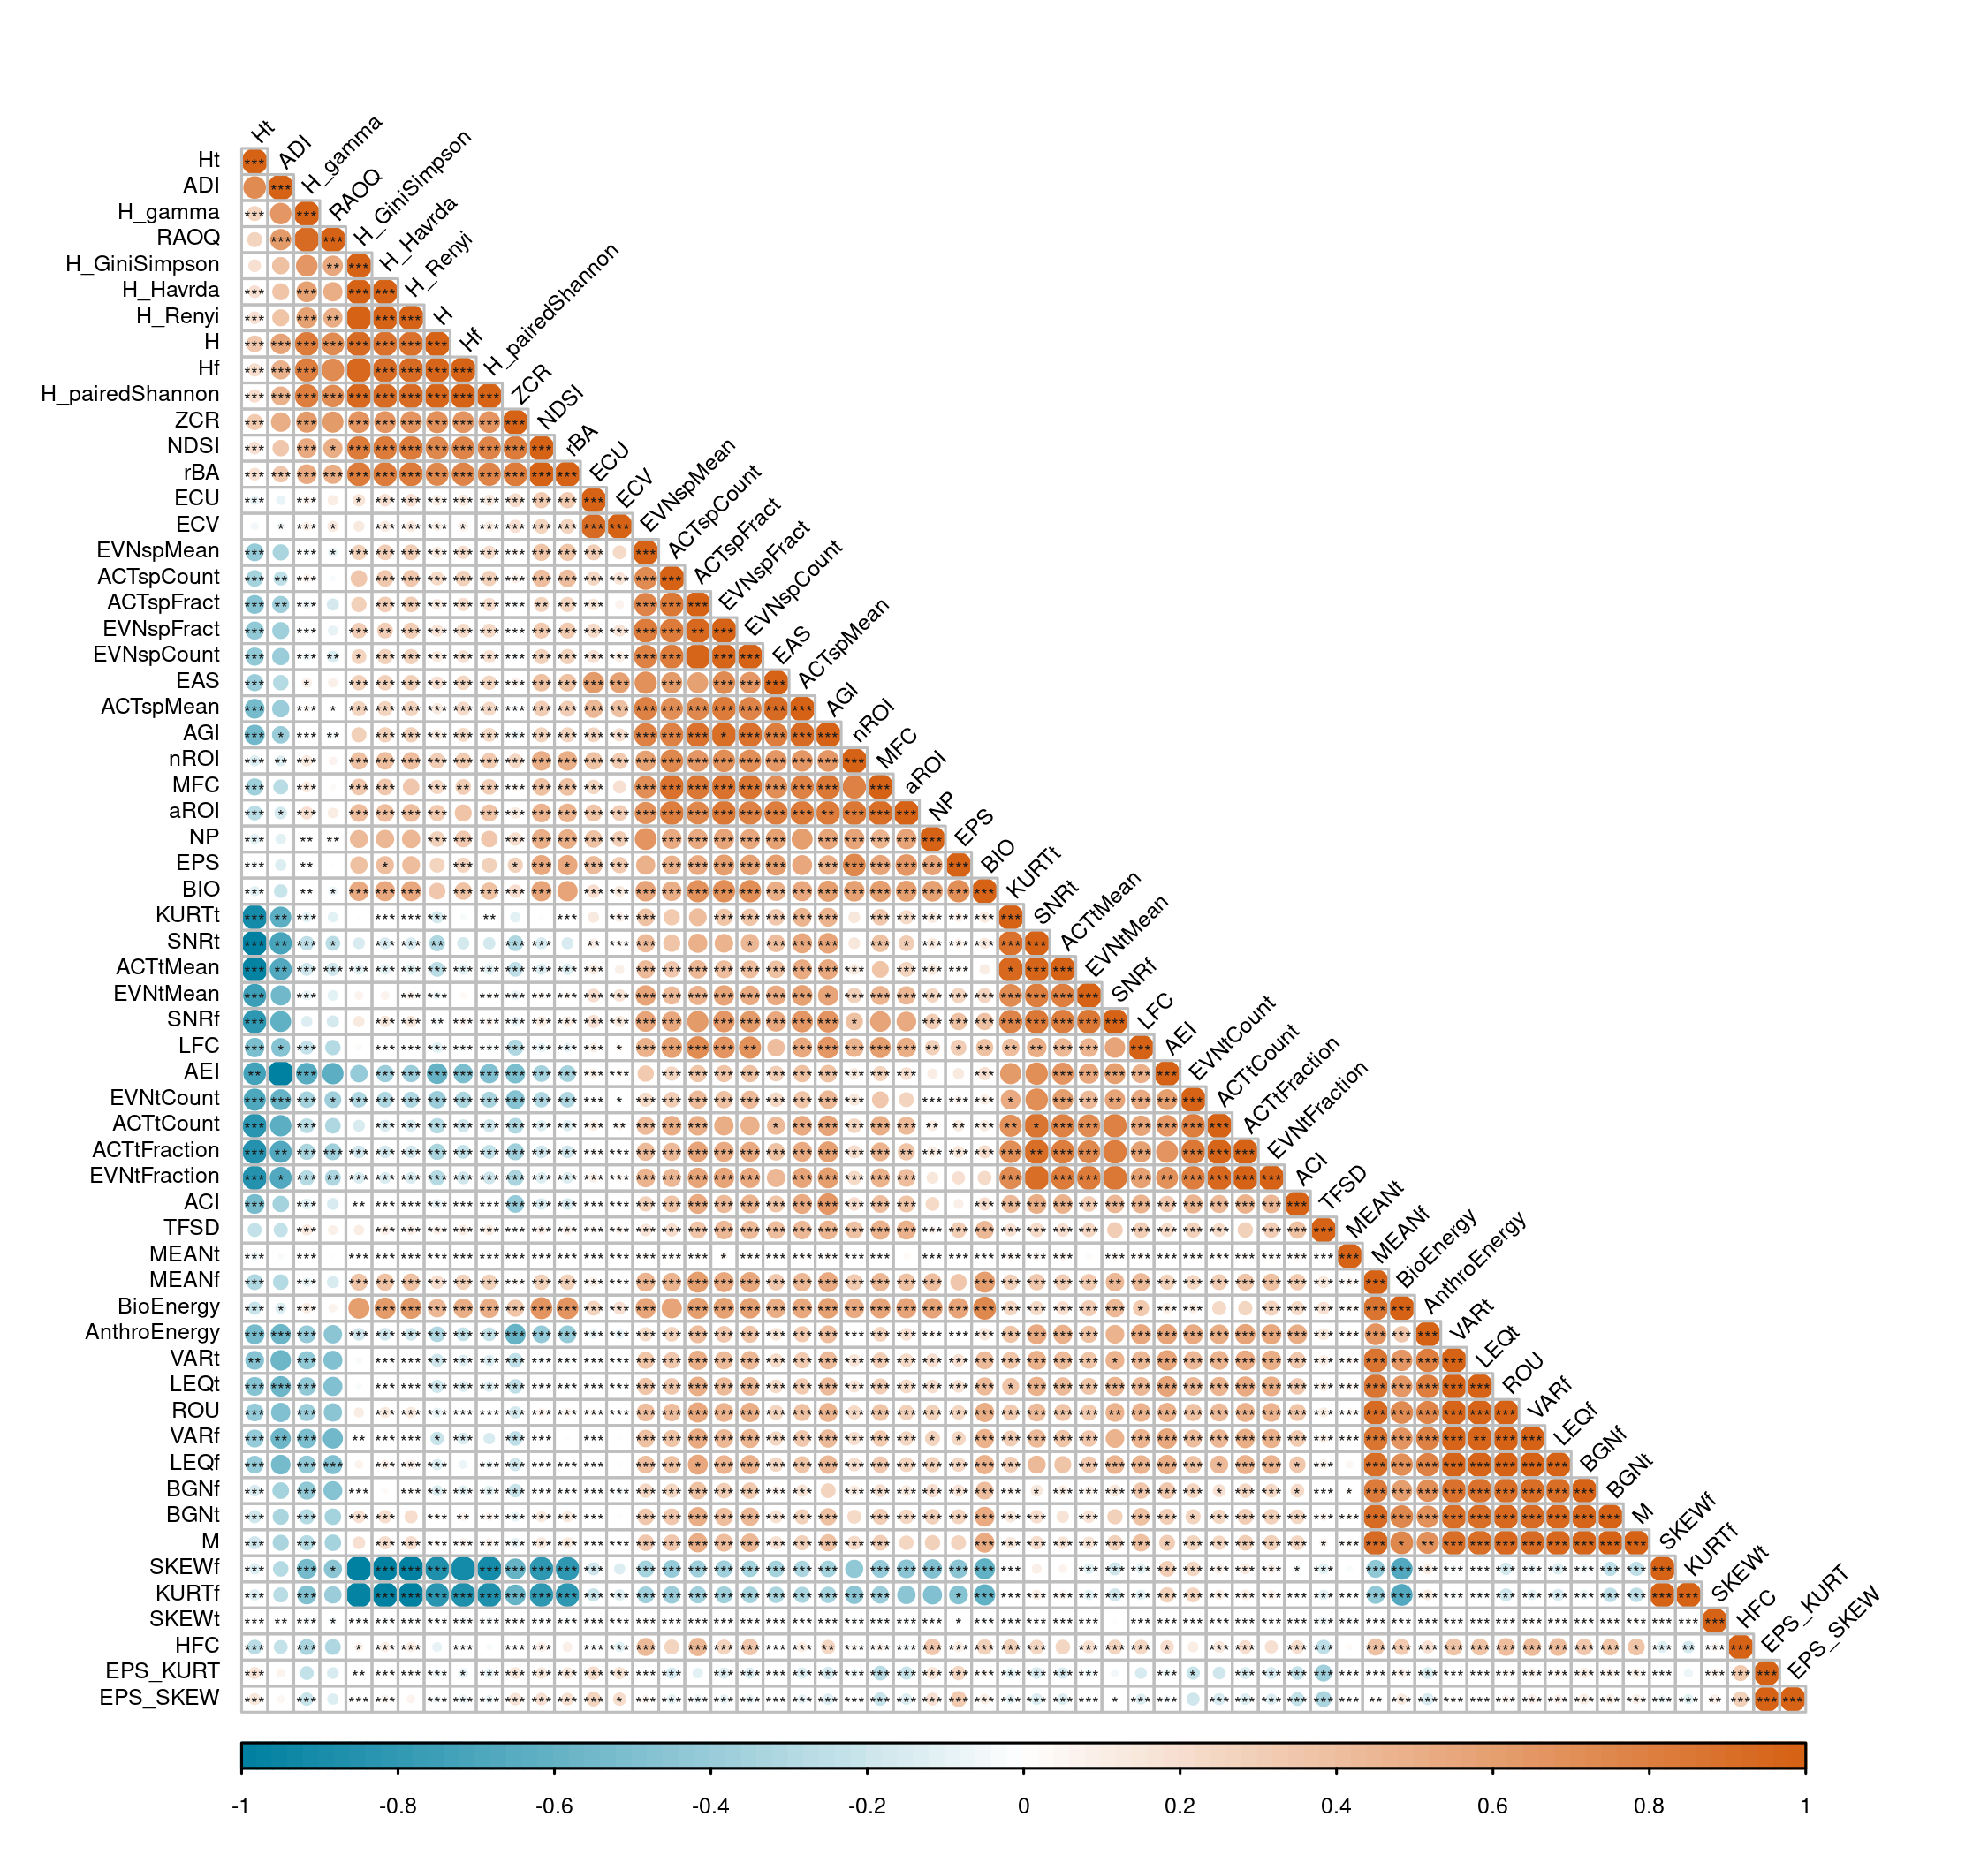

In [86]:
# Resize the figure 
options(repr.plot.width = 7.5, repr.plot.height = 7, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index, method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.4, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 45,
      tl.cex = 0.5,
      cl.ratio = 0.075,
      cl.cex = 0.5
)

# Find the indices of correlations with abs(R) > 0.75 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.75 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
      indice1 = rownames(cor_matrix)[significant_idx[, 1]],
      indice2 = colnames(cor_matrix)[significant_idx[, 2]],
      correlation_r = cor_matrix[significant_idx],
      pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)


Find the correlation between the indices that correlate with species richness

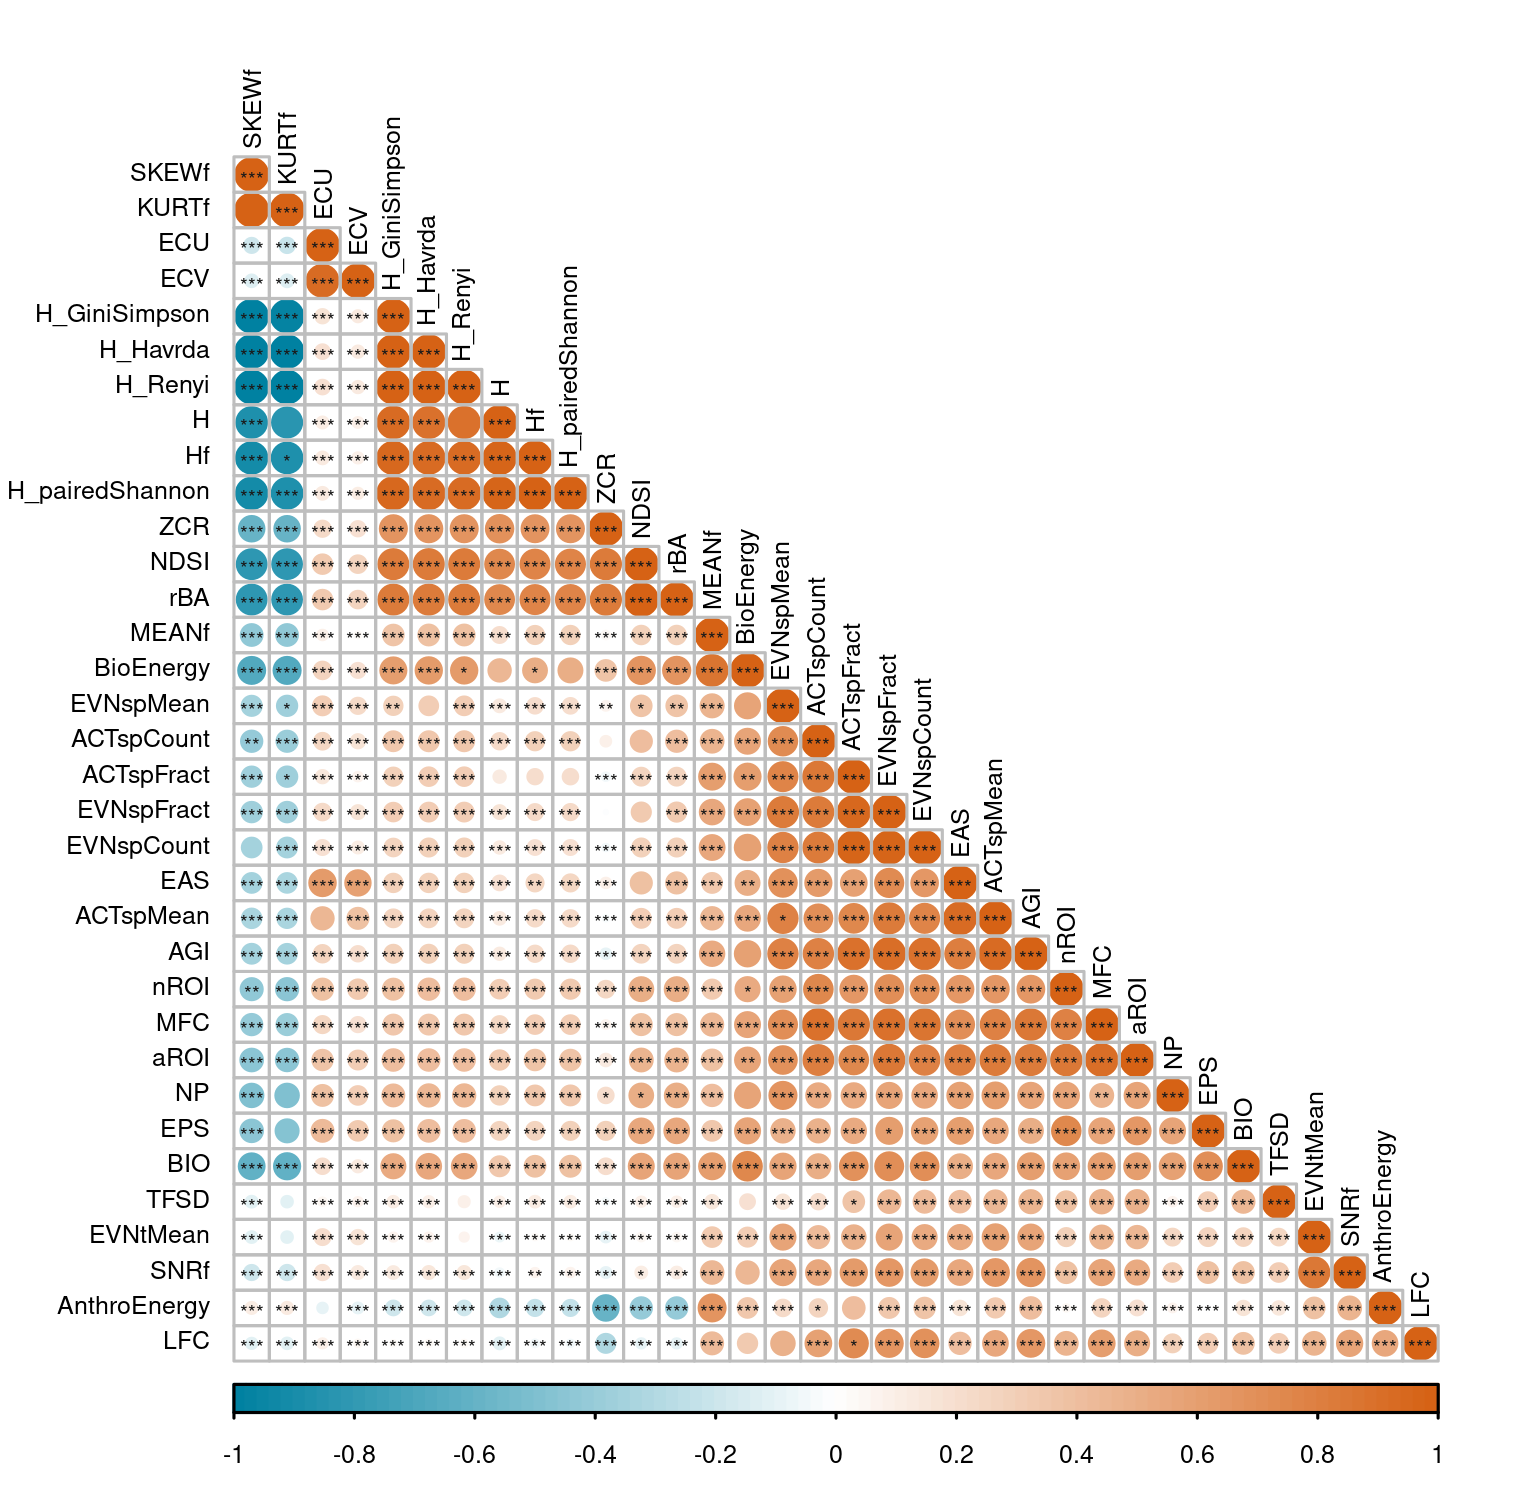

In [83]:
# select the columns by their name
data_index_selection = data_index[,c("ZCR", "EVNtMean", 'MEANf', 'SKEWf', 'KURTf', 'NP', 'SNRf'  
                                    ,'Hf', 'H', 'EAS', 'ECU', 'ECV', 'EPS', 'NDSI', 'rBA'
                                    , 'AnthroEnergy',  'BioEnergy', 'BIO', 'LFC', 'MFC', 'ACTspFract'
                                    , 'ACTspCount', 'ACTspMean','EVNspFract', 'EVNspMean', 'EVNspCount'
                                    , 'TFSD', 'H_Havrda', 'H_Renyi', 'H_pairedShannon', 'H_GiniSimpson'
                                    , 'AGI', 'nROI', 'aROI')]

# Resize the figure 
options(repr.plot.width = 5.1, repr.plot.height = 5, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index_selection, method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index_selection, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.4, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 90,
      tl.cex = 0.5,
      cl.ratio = 0.1,
      cl.cex = 0.5
)


In [85]:
# Find the indices of correlations with abs(R) > 0.75 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.75 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
      indice1 = rownames(cor_matrix)[significant_idx[, 1]],
      indice2 = colnames(cor_matrix)[significant_idx[, 2]],
      correlation_r = cor_matrix[significant_idx],
      pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)

# print the unique indice1
print("=================================")
print("The unique indice1 (high multi-collinearity) are ")
print(unique(most_correlated_index$indice1))

[1] "================================="
[1] "The most correlated index are "
           indice1         indice2 correlation_r        pvalue
1              ZCR            NDSI     0.8370190  0.000000e+00
2              ZCR             rBA     0.8370190 8.741200e-101
3         EVNtMean            SNRf     0.8435061 1.543135e-203
4            MEANf       BioEnergy     0.8742904  0.000000e+00
5            SKEWf           KURTf     0.9940026  0.000000e+00
6            SKEWf              Hf    -0.9031577  0.000000e+00
7            SKEWf               H    -0.8647636  0.000000e+00
8            SKEWf            NDSI    -0.8132239  0.000000e+00
9            SKEWf             rBA    -0.8132239  9.525784e-15
10           SKEWf        H_Havrda    -0.9851861  0.000000e+00
11           SKEWf         H_Renyi    -0.9851861  0.000000e+00
12           SKEWf H_pairedShannon    -0.9085685  0.000000e+00
13           SKEWf   H_GiniSimpson    -0.9828758  0.000000e+00
14           KURTf              Hf    -0.

 [1] "ZCR"             "EVNtMean"        "MEANf"           "SKEWf"          
 [5] "KURTf"           "Hf"              "H"               "EAS"            
 [9] "ECU"             "NDSI"            "rBA"             "MFC"            
[13] "ACTspFract"      "ACTspCount"      "ACTspMean"       "EVNspFract"     
[17] "EVNspMean"       "EVNspCount"      "H_Havrda"        "H_Renyi"        
[21] "H_pairedShannon" "AGI"             "nROI"           


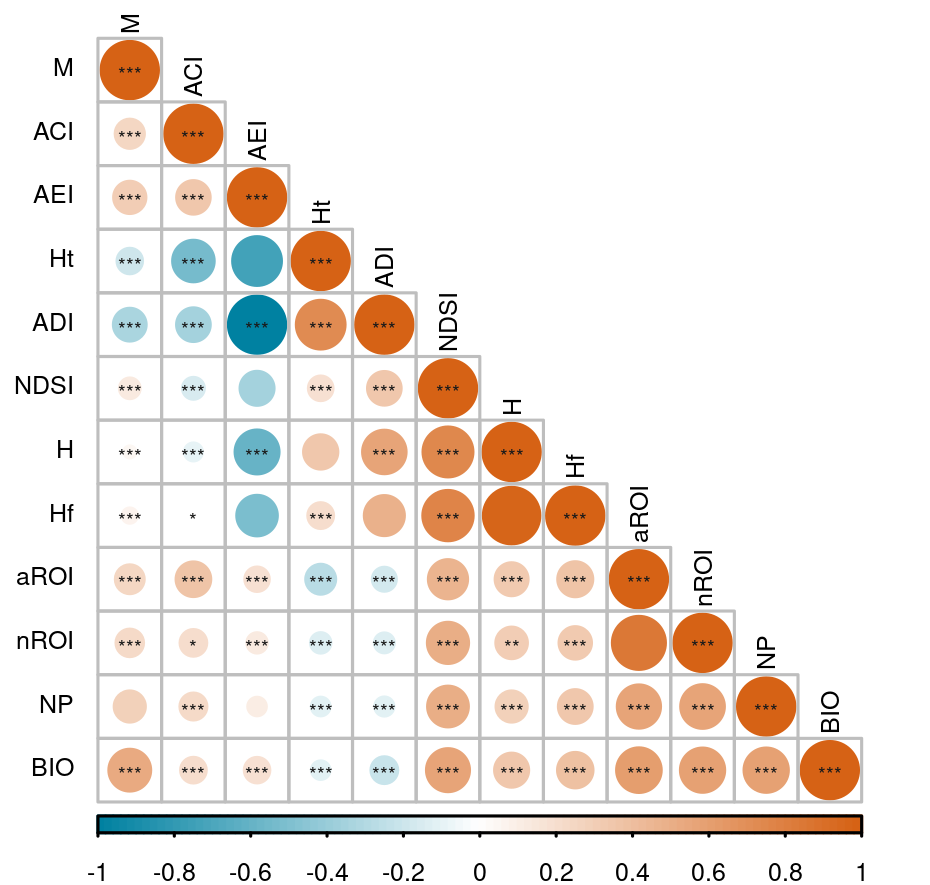

In [ ]:
# select the columns by their name 
data_index_selection = data_index[,c("ACI", "H", "BIO", "NDSI","AEI", "ADI")]

# Resize the figure 
options(repr.plot.width = 3.1, repr.plot.height = 2.95, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index_selection, method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index_selection, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.4, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 90,
      tl.cex = 0.5,
      cl.ratio = 0.1,
      cl.cex = 0.5
)

In [46]:
# Find the indices of correlations with abs(R) > 0.90 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.90 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
  indice1 = rownames(cor_matrix)[significant_idx[, 1]],
  indice2 = colnames(cor_matrix)[significant_idx[, 2]],
  correlation_r = cor_matrix[significant_idx],
  pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)

[1] "================================="
[1] "The most correlated index are "
  indice1 indice2 correlation_r pvalue
1       H      Hf     0.9714799      0
2     AEI     ADI    -0.9975240      0


In [47]:
# Find the indices of correlations with abs(R) < 0.1 and p-value > 0.001
nonsignificant_idx <- which(abs(cor_matrix) < 0.10 & pvalue_matrix > 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
nonsignificant_idx <- unique(t(apply(nonsignificant_idx, 1, sort)))

# Extract parameters based on significant indices
less_correlated_index <- data.frame(
  indice1 = rownames(cor_matrix)[nonsignificant_idx[, 1]],
  indice2 = colnames(cor_matrix)[nonsignificant_idx[, 2]],
  correlation_r = cor_matrix[nonsignificant_idx],
  pvalue = pvalue_matrix[nonsignificant_idx]
)

print("=================================")
print("The less correlated index are ")
print(less_correlated_index)

[1] "================================="
[1] "The less correlated index are "
  indice1 indice2 correlation_r      pvalue
1     ACI      Hf   0.005188355 0.903577364
2      Hf       M   0.071247390 0.005052809
